## 13. Customer Segmentation using Hierarchical Clustering

A retail company wants to group customers based on **Annual Income** and **Spending Score** for targeted marketing.

**Dataset:**  
[Mall Customer Segmentation (Kaggle)](https://www.kaggle.com/datasets/shwetabh123/mall-customers)

### Tasks:

a. Preprocess the data  
   - Handle missing values  
   - Apply encoding (if required)  
   - Perform feature scaling  

b. Apply **Hierarchical Clustering** and plot the **dendrogram**

c. Visualize clusters using:  
   - Annual Income vs Spending Score  

d. Interpret and describe each customer segment

***By Apurv Saktepar, Roll No. 11, SY-SEDA, PRN - 1252090011***

1. Import required libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.cluster.hierarchy as sch
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

2. Load Dataset

In [2]:
df = pd.read_csv('Mall_Customers (1).csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


3. Dataset Information

In [3]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


4. Data Preprocessing

In [7]:
df['Genre'] = df['Genre'].map({'Male': 1, 'Female': 0})
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


5. Feature Scaling

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992],
       [-1.66266033,  1.00159627],
       [-1.62449091, -1.71591298],
       [-1.62449091,  1.70038436],
       [-1.58632148, -1.83237767],
       [-1.58632148,  0.84631002],
       [-1.58632148, -1.4053405 ],
       [-1.58632148,  1.89449216],
       [-1.54815205, -1.36651894],
       [-1.54815205,  1.04041783],
       [-1.54815205, -1.44416206],
       [-1.54815205,  1.11806095],
       [-1.50998262, -0.59008772],
       [-1.50998262,  0.61338066],
       [-1.43364376, -0.82301709],
       [-1.43364376,  1.8556706 ],
       [-1.39547433, -0.59008772],
       [-1.39547433,  0.88513158],
       [-1.3573049 , -1.75473454],
       [-1.3573049 ,  0.88513158],
       [-1.24279661, -1.4053405 ],
       [-1.24279661,  1.23452563],
       [-1.24279661, -0.7065524 ],
       [-1.24279661,  0.41927286],
       [-1.20462718,

6. Plot Dendrogram

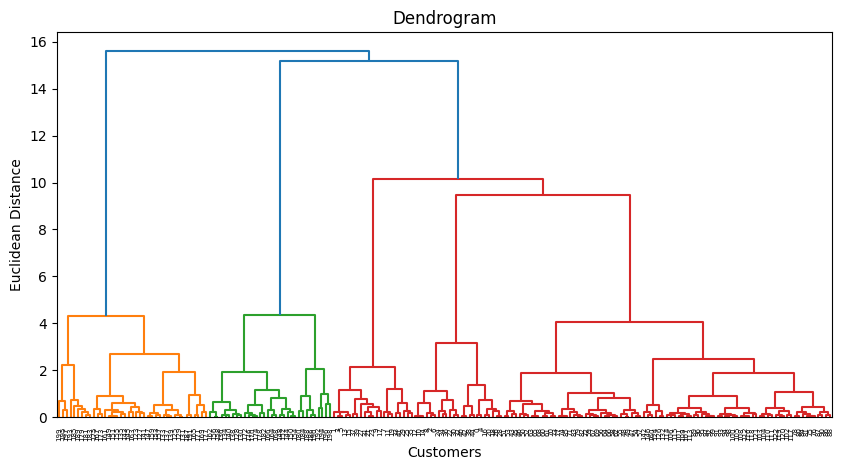

In [10]:
plt.figure(figsize=(10,5))
sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distance')
plt.show()

7. Hierarchical Clustering

In [11]:
hc = AgglomerativeClustering(n_clusters=5, linkage='ward')
y_pred = hc.fit_predict(X_scaled)
df['Cluster'] = y_pred

8. Visualizing clusters

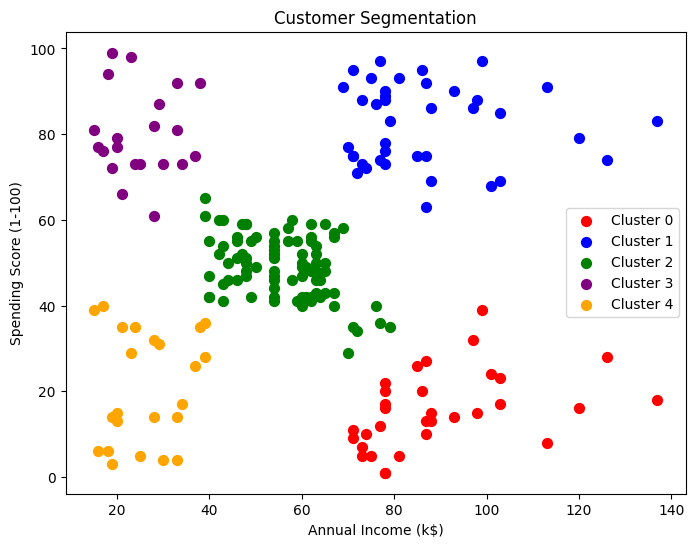

In [14]:
plt.figure(figsize=(8,6))
colors = ['red', 'blue', 'green', 'purple', 'orange']
for i in range(5):
    plt.scatter(
        df[df['Cluster']==i]['Annual Income (k$)'],
        df[df['Cluster']==i]['Spending Score (1-100)'],
        s=50,
        c=colors[i],
        label=f'Cluster {i}'
    )
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segmentation')
plt.legend()
plt.show()

9. Understanding patterns from clusters
* Cluster 0: High income, high spending → Premium customers
* Cluster 1: High income, low spending → Careful customers
* Cluster 2: Low income, high spending → Impulsive buyers
* Cluster 3: Low income, low spending → Budget customers
* Cluster 4: Medium income & spending → Average customers

10. Evaluation

In [15]:
from sklearn.metrics import silhouette_score
score = silhouette_score(X_scaled, y_pred)
print("Silhouette Score:", score)

Silhouette Score: 0.5538089226688662


This silhouette score shows that the clustering resulted as good clustering because score is >= 0.5 and clusters are reasonably well separated and meaningful for customer segmentation.